In [1]:
!nvidia-smi

Sat May 23 07:34:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


# Install YOLOv11

In [3]:
%pip install "ultralytics<=8.3.40" supervision roboflow
# prevent ultralytics from tracking your activity
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.5/112.6 GB disk)


In [ ]:
!pip install roboflow --quiet

from roboflow import Roboflow
rf = Roboflow(api_key="ROBOFLOW_API_KEY")
project = rf.workspace("hohuy").project("valorant-wi1vs")
version = project.version(4)
dataset = version.download("yolov11")
                

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov11 in progress : 41.0%
Version export complete for yolov11 format



Extracting Dataset Version Zip to Valorant-4 in yolov11:: 100%|██████████| 323/323 [00:00<00:00, 6471.33it/s]


In [6]:
# !ls *.pt
# !wget https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11s.pt

# Training

In [8]:
%cd {HOME}

!yolo task=detect mode=train model=yolo11s.pt data={dataset.location}/data.yaml epochs=100 imgsz=640 plots=True

/content
New https://pypi.org/project/ultralytics/8.4.53 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/Valorant-4/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False

In [9]:
!ls {HOME}/runs/detect/train/

args.yaml					    results.png
confusion_matrix_normalized.png			    train_batch0.jpg
confusion_matrix.png				    train_batch1.jpg
events.out.tfevents.1779521804.0dc322183ce0.1448.0  train_batch2.jpg
F1_curve.png					    train_batch810.jpg
labels_correlogram.jpg				    train_batch811.jpg
labels.jpg					    train_batch812.jpg
P_curve.png					    val_batch0_labels.jpg
PR_curve.png					    val_batch0_pred.jpg
R_curve.png					    weights
results.csv


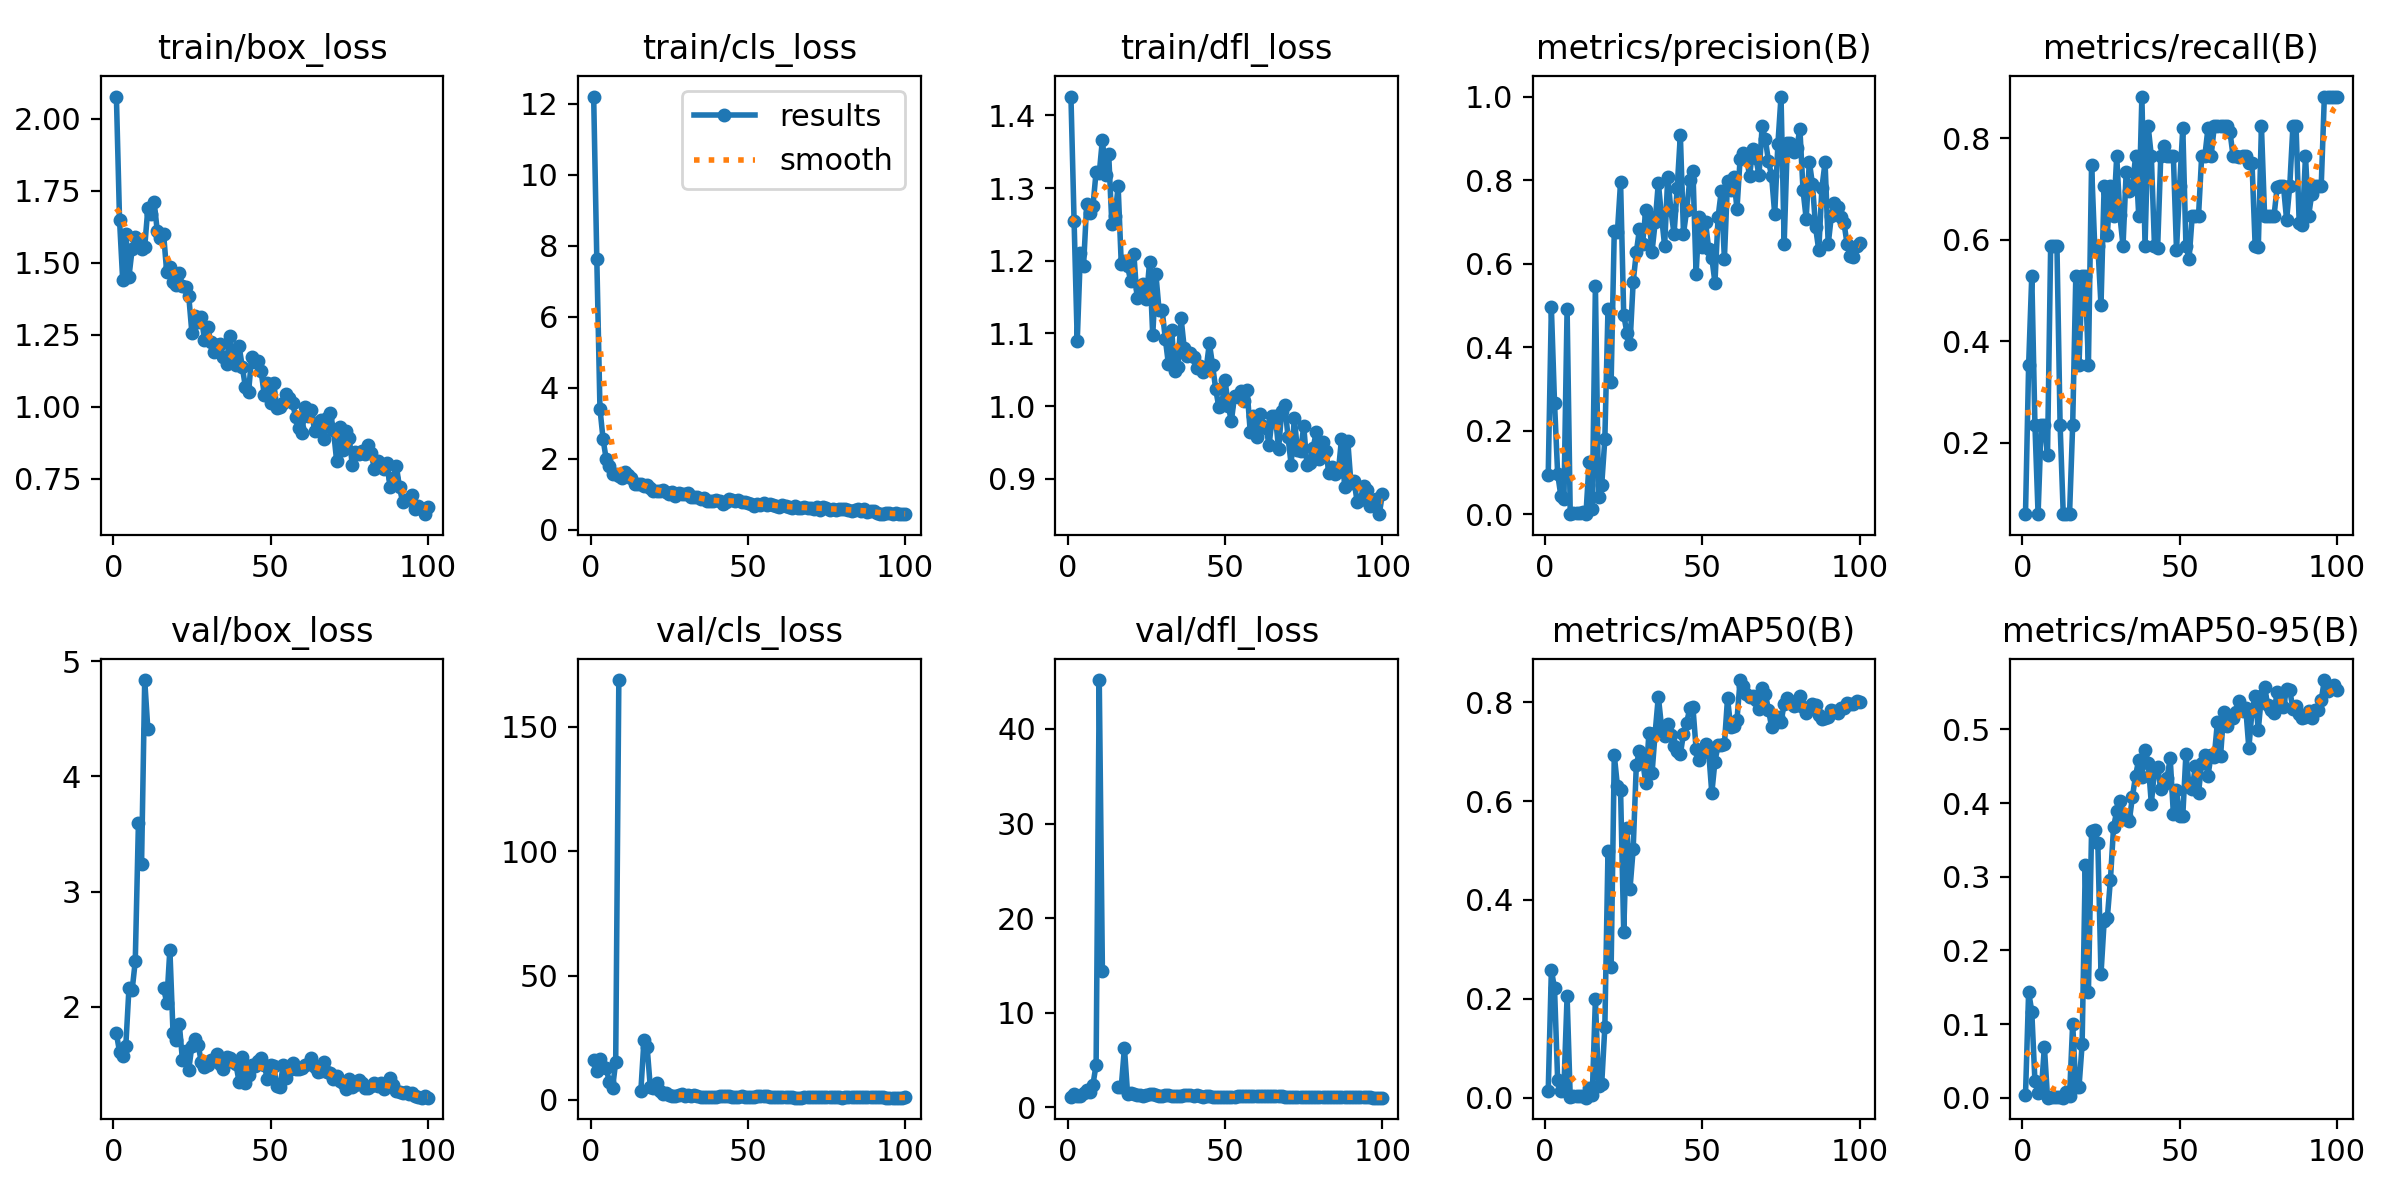

In [10]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/results.png', width=600)

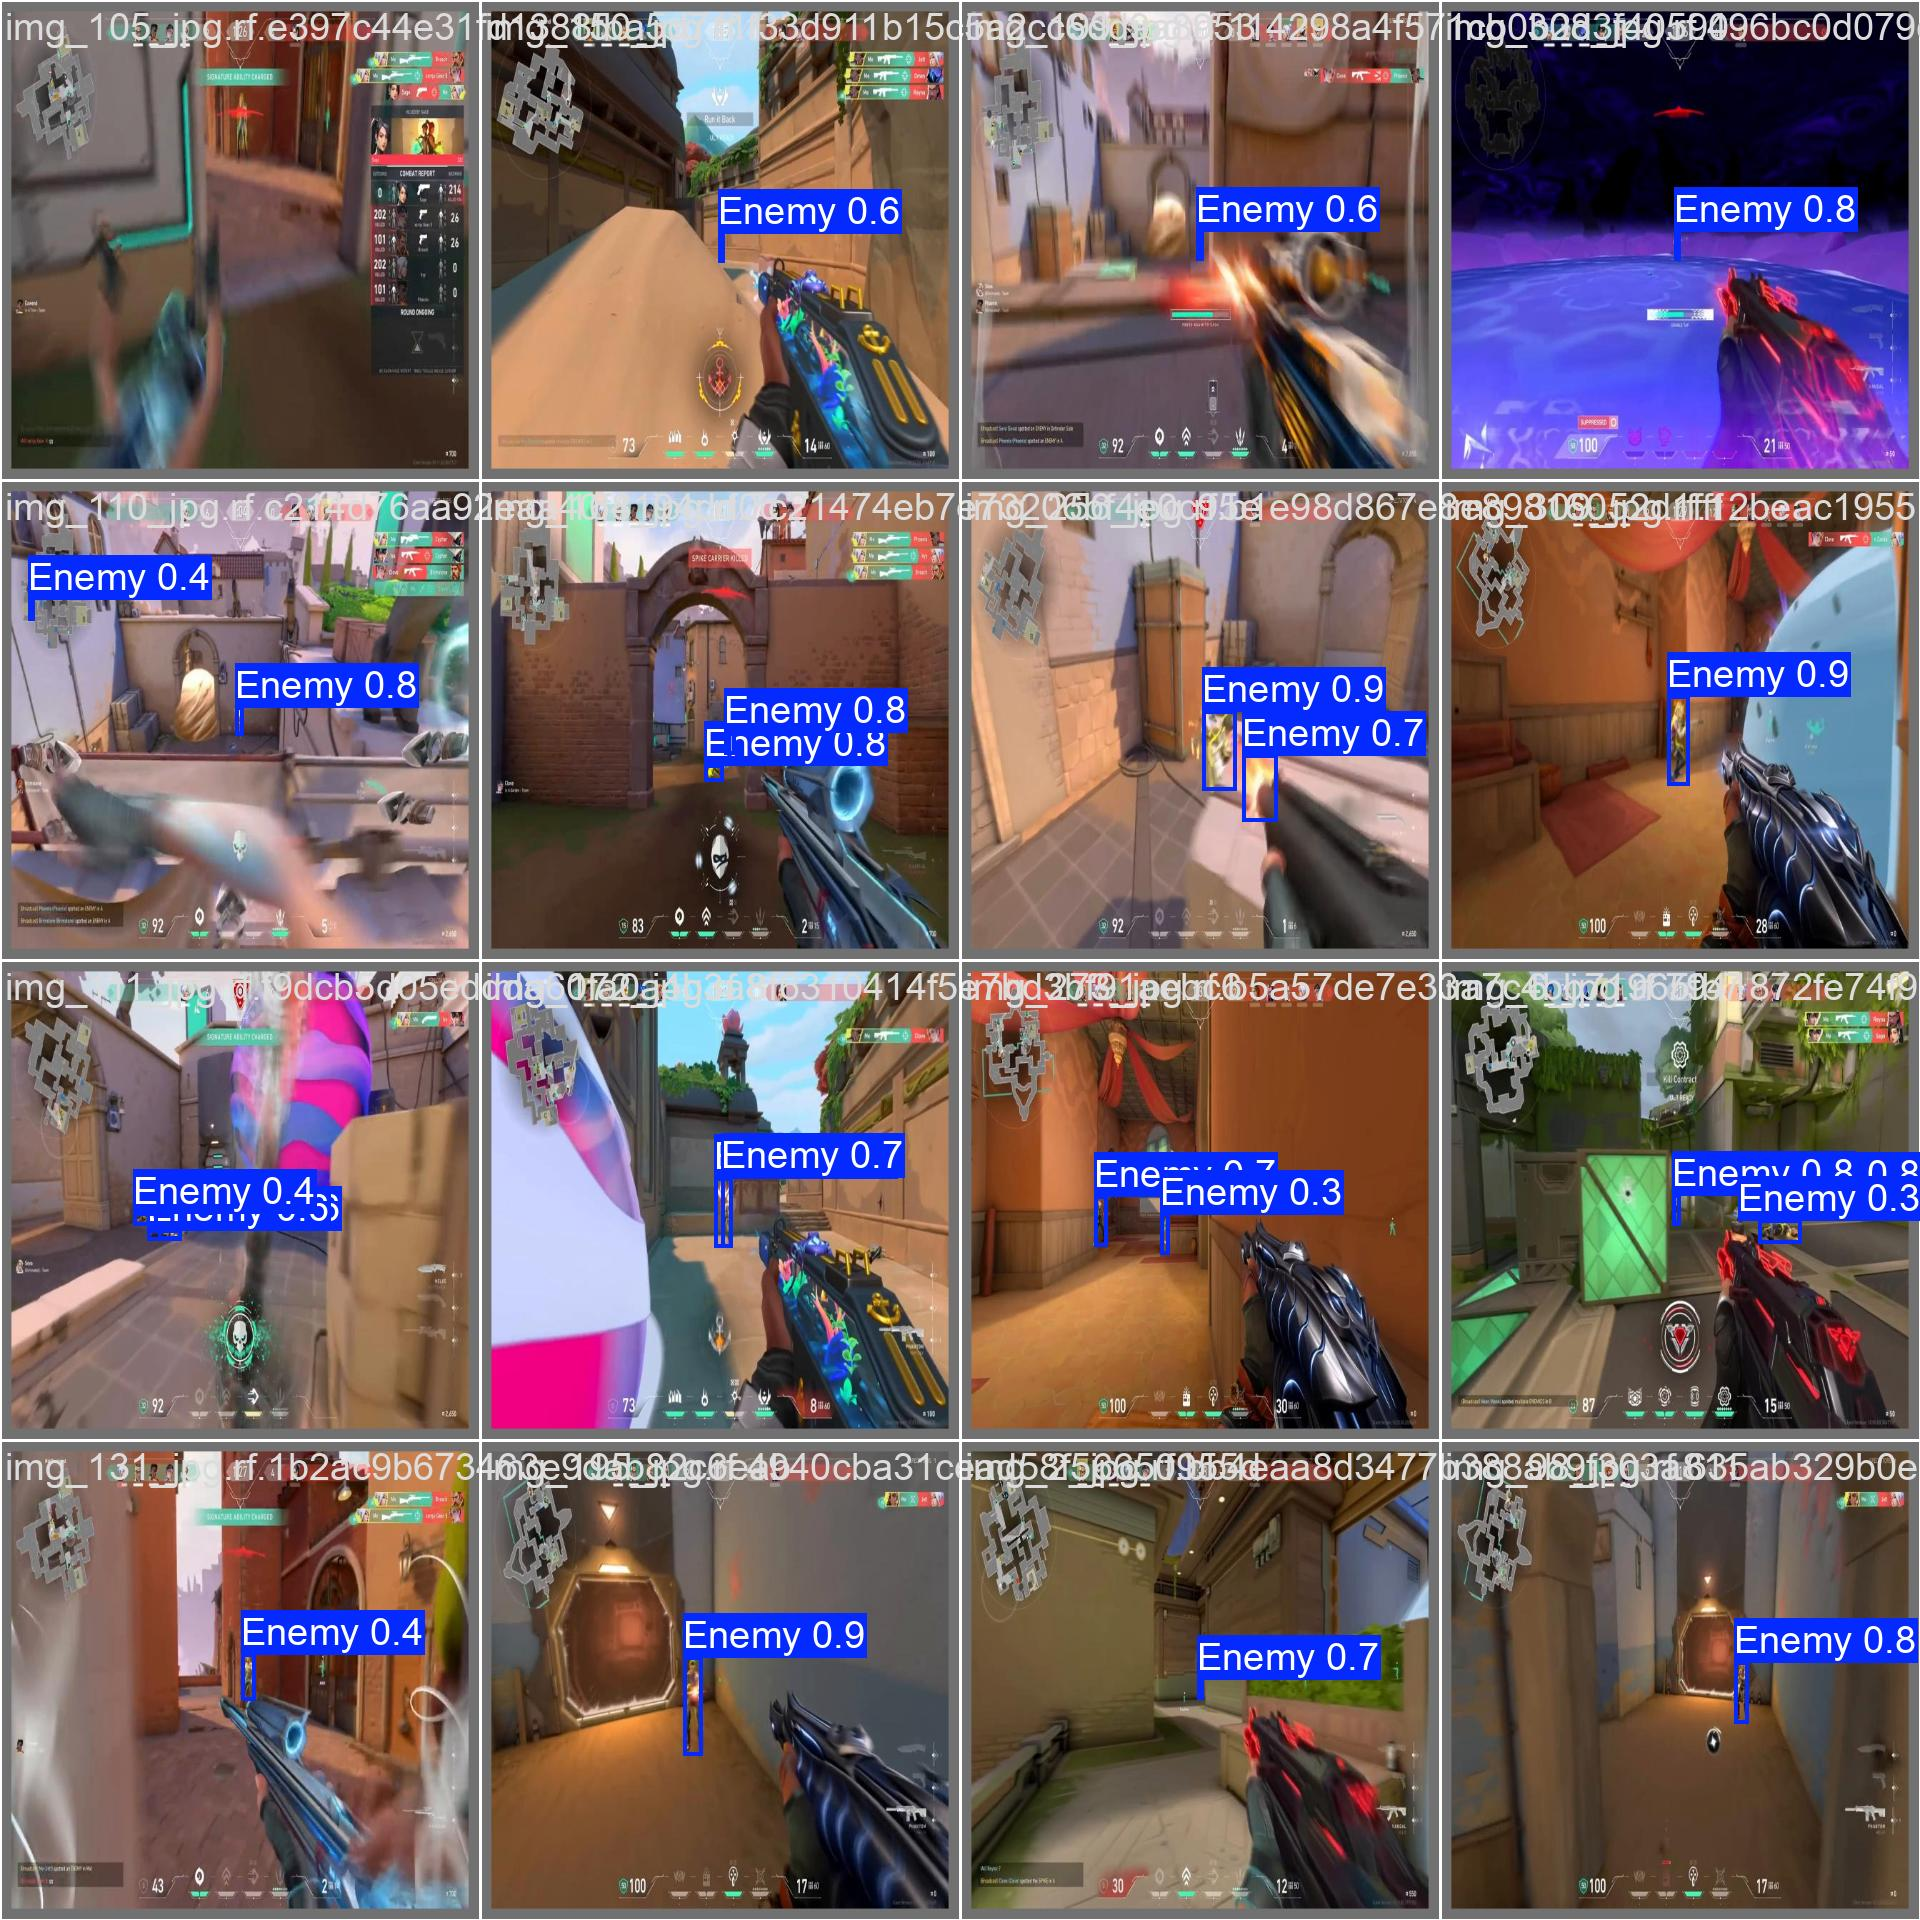

In [11]:
IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

# Validate

In [12]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 238 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs
val: Scanning /content/Valorant-4/valid/labels.cache... 16 images, 2 backgrounds, 0 corrupt: 100% 16/16 [00:00<?, ?it/s]
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 16, len(boxes) = 17. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 1/1 [00:00<00:00,  1.98it/s]
                   all         16         17       0.62      0.882      0.794      0.563
Speed: 0.2ms preprocess, 12.1ms inference, 0.0ms loss, 8.2ms postprocess per image
Results saved to runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


In [13]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 238 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs

image 1/8 /content/Valorant-4/test/images/img_213_jpg.rf.fe406702b7e3a24b7f3348f49087643d.jpg: 640x640 1 Enemy, 15.5ms
image 2/8 /content/Valorant-4/test/images/img_22_jpg.rf.70533d4ead51a3d6fda1eb1cfbad52ca.jpg: 640x640 2 Enemys, 15.2ms
image 3/8 /content/Valorant-4/test/images/img_26_jpg.rf.26d53cdefcfb33ff4c707c205887be67.jpg: 640x640 1 Enemy, 15.2ms
image 4/8 /content/Valorant-4/test/images/img_36_jpg.rf.446b7a940ca170ebf808621a0480273c.jpg: 640x640 1 Enemy, 15.2ms
image 5/8 /content/Valorant-4/test/images/img_40_jpg.rf.49b4b1d7cbf6fb1168f96686307e02c2.jpg: 640x640 1 Enemy, 15.2ms
image 6/8 /content/Valorant-4/test/images/img_4_jpg.rf.0186cd047fa3240fba10776da1603bf0.jpg: 640x640 2 Enemys, 15.2ms
image 7/8 /content/Valorant-4/test/images/img_54_jpg.rf.9439a5702516c10bf29baea457c7ae2a.jpg: 640x640 2 Enemys, 15.1ms
ima

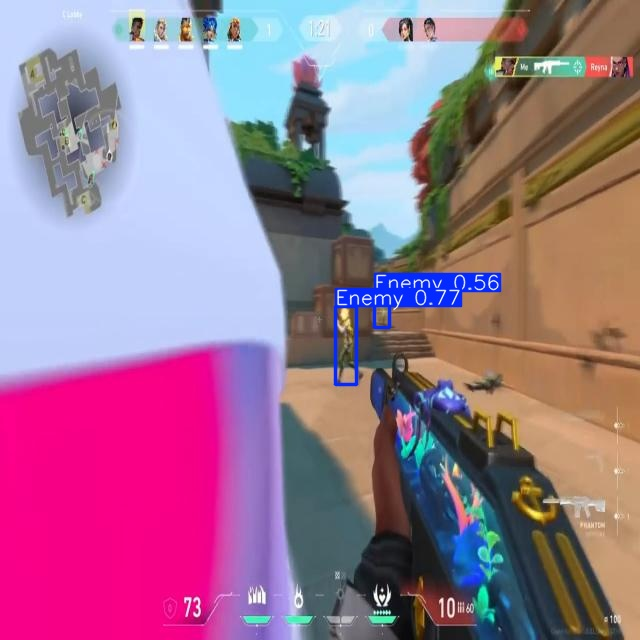

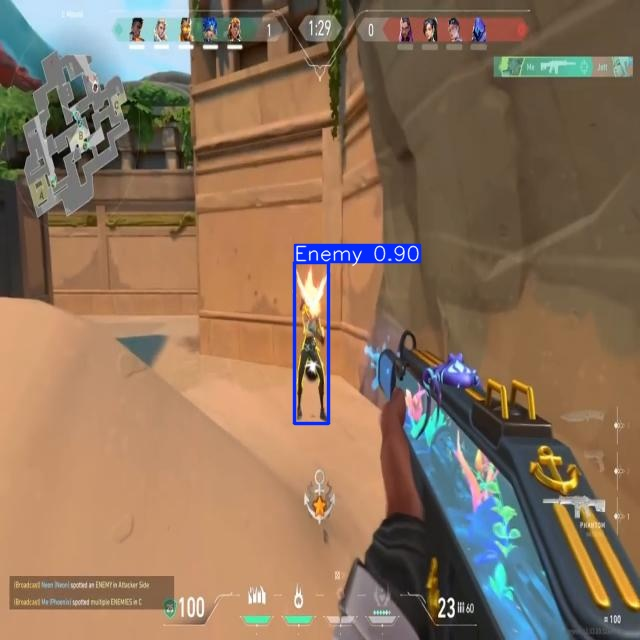

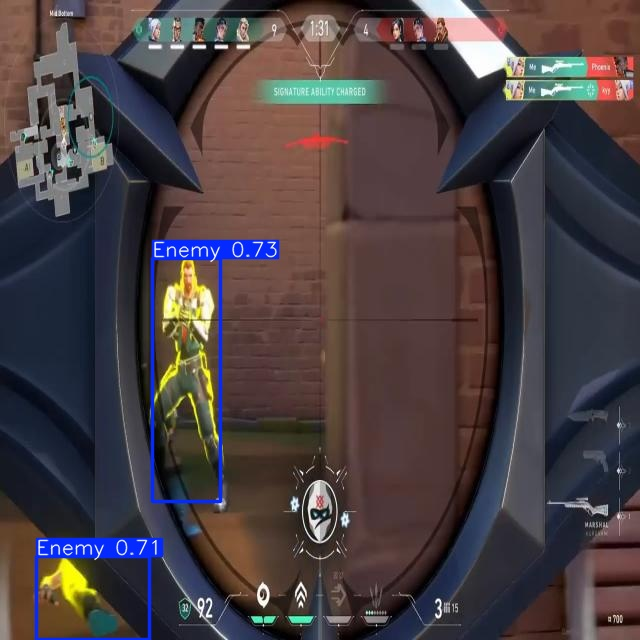

In [14]:
import glob

latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")